TASK 2A

CELL 1: Importing necessary libraries and setting up the environment

Starting by importing what we need, including the pretrained CNN we've chosen (EfficientNetB0) which we'll get back to.

The reason we've chosen to use a pretrained model instead of training a model from scratch is that pretrained models have already been 
trained on large datasets and have learned useful features that can be applied to our specific task. 
This allows us to leverage the knowledge and patterns that the pretrained model has already learned, which can lead to faster convergence 
and improved performance, especially when we have a limited amount of data for training. 
Additionally, using a pretrained model saves time and computational resources compared to training a model from scratch.

In [73]:
#CELL 1: Importing necessary libraries and setting up the environment

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
print(os.listdir("art"))

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt


['AiArtData', '.DS_Store', 'RealArt']


CELL 2: Settings

This model is originally trained on IMG_SIZE = (224, 224), but we've chosen to reduce it to speed up training. 
But larger sizes could potentially improve accuracy, as the model would have more detailed information to learn from.
Larger sizes would require more computational resources and longer training times, so it's a trade-off between accuracy and efficiency.
We could experiment with different sizes to find the optimal balance for our specific dataset and hardware capabilities.

We've chosen 64 as the batch size to balance between training speed and memory usage. 
A larger batch size can speed up training by allowing more samples to be processed in parallel, but it also requires more memory. 
A smaller batch size can reduce memory usage but may lead to longer training times. 
By selecting a batch size of 64, we aim to achieve efficient training while managing memory constraints effectively.

We've chosen to set EPOCHS to 10 to allow the model enough time to learn from the data without overfitting.

We figured these settings would provide a good, balanced starting point for training our model, 
allowing it to learn effectively while managing computational resources.

In [74]:
#CELL 2: Settings
DATA_DIR = "art"
IMG_SIZE = (150, 150)
BATCH_SIZE = 64
EPOCHS = 10

CELL 3: Creating training and evaluation datasets, and splitting the evaluation dataset into validation and test datasets.

Originally this model only has a training set and a validation set. We split the validation set in two, so we have a separate test set to 
evaluate the final model on. The training set is used to train the model, the validation set is used to tune hyperparameters and make 
decisions about the model architecture, and the test set is used to evaluate the final performance of the model after all tuning is done.

As you can see we've set the training set to be 80% of the data, and the remaining 20% is split into 10% for validation and 10% for testing.
This way we have a good amount of data for training while still having enough data to evaluate the model's performance on unseen data as well
as testing it on a separate test set to get an unbiased estimate of its performance.

This is standard practice in Machine Learning.

In [75]:
#CELL 3: Creating training and evaluation datasets, and splitting the evaluation dataset into validation and test datasets.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

eval_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

eval_batches = len(eval_dataset)
val_batches = eval_batches // 2

val_dataset = eval_dataset.take(val_batches)
test_dataset = eval_dataset.skip(val_batches)

class_names = train_dataset.class_names
print("Klassar:", class_names)
print(f"Train batches: {len(train_dataset)}, Val batches: {len(val_dataset)}, Test batches: {len(test_dataset)}")

Found 962 files belonging to 2 classes.
Using 770 files for training.
Found 962 files belonging to 2 classes.
Using 192 files for validation.
Klassar: ['AiArtData', 'RealArt']
Train batches: 13, Val batches: 1, Test batches: 2


CELL 4: Visualizing some of the training data to understand what the model will be trained on.

We've visualized some of the training data to get a sense of what the model will be trained on. This helps us understand the diversity and 
characteristics of the images in our dataset, which informs our decisions about model architecture and training strategies.

By looking at the training data visually, we can assess the diversity and difficulty of the classification task. Since the differences between real and AI-generated images are subtle, this informs our decision to use a pretrained model with strong feature extraction capabilities rather than a simpler architecture. This will be elaborated on in cell 7.

Found 962 files belonging to 2 classes.


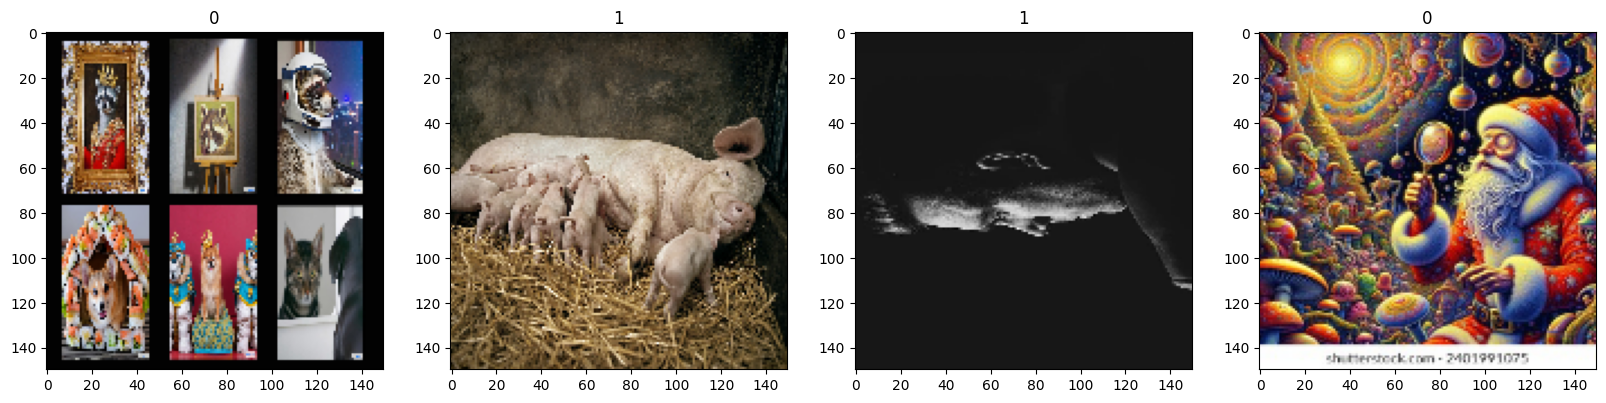

In [96]:
#CELL 4: Visualizing some of the training data to understand what the model will be trained on.

data = tf.keras.utils.image_dataset_from_directory(
    'art',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

#1 = Real
#0 = AI

CELL 5: Performance optimizations for the datasets

Prefetching prepares the next batch of data while the model is still training on the 
current one, reducing waiting time between batches. AUTOTUNE lets TensorFlow automatically 
find the optimal settings based on available resources.

In [77]:
#CELL 5: Performance optimizations for the datasets

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

CELL 6: Data augmentation

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of the existing 
data. 
This can help improve the performance of machine learning models by providing more diverse training examples and reducing overfitting. This is especially important for our task because as shown in cell 4 the images are highly varied when it comes to textures, colors and context.

In [78]:
#CELL 6: Data augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

CELL 7: Pretrained base model

For our task, this is the most important part. We will use a pretrained model called EfficientNetB0. Using a pretrained model is called "Transfer Learning".

The researchers behind EfficientNet discovered that the best way to scale a neural network is to increase three dimensions simultaneously in a fixed ratio: Depth, width and resolution. This is called "Compound scaling" and is what makes the EfficientNet architecture so unique and especially useful when dealing with AI images.

The EfficientNetB0 model has been trained on the ImageNet dataset consisting of millions of images across a thousand categories. Although ImageNet contains no AI-generated images, the low-level features EfficientNetB0 has learned, such as textures, edges and patterns, are directly relevant for detecting the subtle inconsistencies that AI-generated images often contain. By using this as a base, we can leverage these rich feature representations even with a smaller dataset. The EfficientNet architecture is known for having high accuracy with relatively few parameters using compound scaling, and B0 is the smallest and fastest variant, suitable for computers with limited resources such as ours.

We could've used EfficientNetB3 or B4 as they would've given better performance with higher resolution input, meaning more information per image in the form of patterns, edges, textures and inconsistencies. This matters a lot when it comes to AI images because the differences between a real and an AI-generated image are often subtle, and higher resolution with more filters makes it easier to pick up on these differences. However, those models require much more resources, hence why we've gone for a suboptimal model.

We've changed include_top to False so we can replace the original ImageNet classifier with our own binary classifier for this task.

In [79]:
#CELL 7: Pretrained base model

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(150, 150, 3)
)

CELL 8: Building the model

We use training=False when calling the base model to preserve the statistics EfficientNetB0 
learned from ImageNet, since updating them with our relatively small dataset would likely 
make them worse rather than better. GlobalAveragePooling2D and Dropout(0.2) are both chosen 
to reduce the risk of overfitting, which is a concern given our limited dataset size. 
A single sigmoid neuron is used as the output layer since this is a binary classification 
task. It outputs a probability between 0 and 1 representing how likely the image is real.

In [ ]:
#CELL 8: Building the model

inputs = tf.keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

CELL 9: Freezing the base model / Phase 1

We freeze the base model before training to prevent catastrophic forgetting. Since the classification head starts with random weights, it would produce large unstable gradients in the early stages of training. If the base model were not frozen, these would propagate back through EfficientNetB0 and destroy the valuable knowledge it gained from ImageNet. By freezing it, we ensure only the classification head is updated in these 5 epochs, giving it time to stabilize before we allow the entire network to be fine-tuned in cell 10.

In [ ]:
#CELL 9: Freezing the base_model / Phase 1
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 808ms/step - accuracy: 0.5506 - loss: 0.6911 - val_accuracy: 0.5781 - val_loss: 0.6450
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 570ms/step - accuracy: 0.6117 - loss: 0.6494 - val_accuracy: 0.5781 - val_loss: 0.6543
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 570ms/step - accuracy: 0.6584 - loss: 0.6317 - val_accuracy: 0.6875 - val_loss: 0.5980
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 572ms/step - accuracy: 0.6740 - loss: 0.5955 - val_accuracy: 0.6875 - val_loss: 0.5698
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 660ms/step - accuracy: 0.7000 - loss: 0.5769 - val_accuracy: 0.6719 - val_loss: 0.5722


CELL 10: Fine-tuning the entire model / Phase 2

Once the classification head is stable, we unfreeze the base model and allow the entire network to be updated. We reduce the learning rate significantly from 0.001 to 0.00001 because the pretrained weights in EfficientNetB0 are already good, and we only want to make small adjustments towards our specific task rather than overwriting what the model already knows. We use few epochs because with such a low learning rate, major changes are unlikely, and training for too long risks overfitting on our relatively small dataset.

If we had skipped freezing and trained the entire network from the start, the randomly initialized classification head would likely have degraded the pretrained weights before they had a chance to be useful, potentially resulting in lower accuracy and slower convergence than what we see here.

In [ ]:
#CELL 10: Fine-tuning the entire model / Phase 2

base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # mye lavere
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7494 - loss: 0.5285 - val_accuracy: 0.7188 - val_loss: 0.5619
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.7416 - loss: 0.5103 - val_accuracy: 0.6250 - val_loss: 0.6130
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.7636 - loss: 0.5082 - val_accuracy: 0.7969 - val_loss: 0.4955
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7883 - loss: 0.4840 - val_accuracy: 0.7188 - val_loss: 0.5420
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.7818 - loss: 0.4923 - val_accuracy: 0.7344 - val_loss: 0.5224
1e-05


CELL 11: Evaluating the model on a test set

Then we're evaluating the model on a test set, which has been kept completely separate throughout training. This is important because the validation set has indirectly influenced the model through decisions made during training, so using it for final evaluation would give an overly optimistic measure of performance. The test set gives an honest picture of how well the model generalizes to images it has never seen before.

The accuracy plot combines both training phases into one continuous graph, with a vertical line marking where phase 2 begins. This is useful for detecting overfitting and for seeing  whether fine-tuning in phase 2 actually improved the model. If training accuracy keeps rising while validation accuracy plateaus or drops after the phase 2 line, the model is overfitting rather than improving. A test accuracy of 71% reflects the challenge of the task and the limitations of our relatively small dataset and suboptimal model choice.

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.7109 - loss: 0.5611
Test loss: 0.5611
Test accuracy: 0.7109


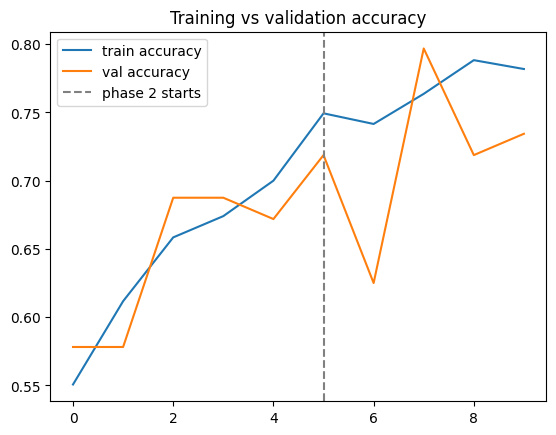

In [ ]:
#CELL 11: Evaluating the model on a test set

test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

phase1_acc = history_phase1.history["accuracy"]
phase1_val = history_phase1.history["val_accuracy"]
phase2_acc = history_phase2.history["accuracy"]
phase2_val = history_phase2.history["val_accuracy"]

all_acc = phase1_acc + phase2_acc
all_val = phase1_val + phase2_val

plt.plot(all_acc, label="train accuracy")
plt.plot(all_val, label="val accuracy")
plt.axvline(x=len(phase1_acc), color="gray", linestyle="--", label="phase 2 starts")
plt.legend()
plt.title("Training vs validation accuracy")
plt.savefig("results_accuracy.png")
plt.show()

CELL 12: Single image prediction

To classify a new image, it must be preprocessed in the same way as the training data, resized to 150x150 and converted to a numpy array. tf.expand_dims is used to add a batch
dimension, since the model expects input of shape (batch_size, 150, 150, 3) even when
predicting on a single image.

The sigmoid output represents the probability of the image being "Real". Since this is a
binary classifier, the AI probability is simply 1 minus the real probability. The decision
threshold is set at 0.5, meaning the model predicts "Real" if the probability exceeds 50%
and "AI" otherwise. This threshold could be adjusted depending on whether you want to
prioritize precision or recall - for example, lowering it would flag more images as AI,
reducing false negatives at the cost of more false positives.

For part b, this cell is run 5 times with different images, both real photographs and
AI-generated images, to evaluate how well the model performs on unseen data in practice.

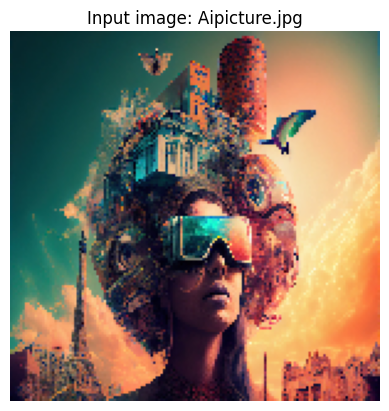

Probability Real: 27.59%
Probability AI: 72.41%
Predicted class: AI
Confidence: 72.41%


In [100]:
#CELL 12: Making predictions on new images

image_path = "Aipicture.jpg"

img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_batch = tf.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.title(f"Input image: {image_path}")
plt.axis("off")
plt.show()

prediction = model.predict(img_batch, verbose=0)[0][0]

real_probability = float(prediction)
ai_probability = float(1 - prediction)
predicted_label = "Real" if real_probability > 0.5 else "AI"
confidence = max(real_probability, ai_probability)

print(f"Probability Real: {real_probability:.2%}")
print(f"Probability AI: {ai_probability:.2%}")
print(f"Predicted class: {predicted_label}")
print(f"Confidence: {confidence:.2%}")
